# Yield Curve Bootstrapping

This notebook demonstrates:
- Curve construction
- Forward rate extraction
- Multi-curve pricing
- DV01 sensitivity

## Step 1: Load packages and functions

In [1]:
import sys
sys.path.append("../python")

import numpy as np
import matplotlib.pyplot as plt

from bootstrap_single_curve import bootstrap_single_curve
from bootstrap_multi_curve import build_ois_curve, build_libor_curve
from pricer import price_swap
from risk import dv01

## Step 2: Load data and build curves

In [2]:
csv_path = "../data/market_data_sample.csv"

single_curve = bootstrap_single_curve(csv_path)
ois_curve = build_ois_curve(csv_path)
libor_curve = build_libor_curve(csv_path)

In [3]:
single_curve.zero_rate(5.0)

np.float64(0.0388826327812577)

## Step 3: Zero Curve

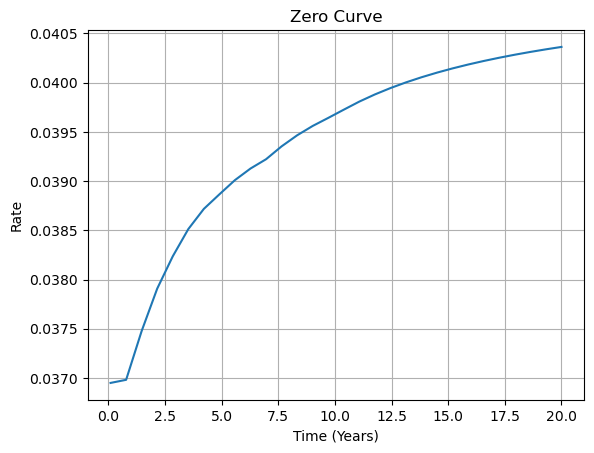

In [4]:
times = np.linspace(0.1, 20, 30)

zero_rates = [single_curve.zero_rate(t) for t in times]

plt.figure()
plt.plot(times, zero_rates)
plt.title("Zero Curve")
plt.xlabel("Time (Years)")
plt.ylabel("Rate")
plt.grid()
plt.show()

In [5]:
# Show the time-series of discount factors
single_curve.df_interp.values

[np.float64(0.9969214152571394),
 np.float64(0.9908421905166154),
 np.float64(0.9815719124925191),
 np.float64(0.9637725077811297),
 np.float64(0.9271870071971895),
 np.float64(0.8914846765311315),
 np.float64(0.8233176688427426),
 np.float64(0.7598891921143407),
 np.float64(0.6725189498494605),
 np.float64(0.4460897636385872),
 np.float64(0.305257882219152)]

In [6]:
# Check whether the discout factors are monotone decreasing with time
dfs = [single_curve.get_df(t) for t in times]

print(all(dfs[i] >= dfs[i+1] for i in range(len(dfs)-1)))

True


## Step 4: Forward Curve

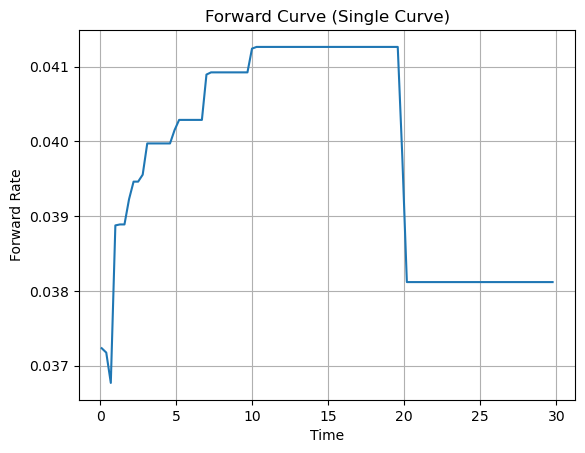

In [7]:
max_t = max(single_curve.df_interp.times)
times = np.linspace(0.1, max_t - 0.25, 100)
fwds = [single_curve.forward_rate(t, t+0.25) for t in times]

plt.figure()
plt.plot(times, fwds)
plt.title("Forward Curve (Single Curve)")
plt.xlabel("Time")
plt.ylabel("Forward Rate")
plt.grid()
plt.show()

## Step 5: Multi-Curve Forward

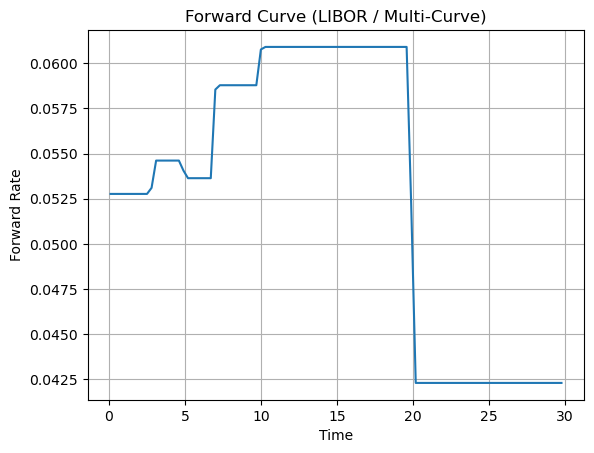

In [8]:
fwds_libor = [libor_curve.forward_rate(t, t+0.25) for t in times]

plt.figure()
plt.plot(times, fwds_libor)
plt.title("Forward Curve (LIBOR / Multi-Curve)")
plt.xlabel("Time")
plt.ylabel("Forward Rate")
plt.grid()
plt.show()

## Step 6: Swap Pricing

In [9]:
pv = price_swap(ois_curve, libor_curve, maturity=5, fixed_rate=0.055)

print("Swap PV:", pv)

Swap PV: -0.0020327911834782386


## Step 7: DV01

In [10]:
dv = dv01(csv_path, maturity=5)

print("DV01:", dv)

DV01: -0.0003184759678297455


### Observations

- Zero curve is smooth and upward sloping
- Forward curve is more volatile (sensitive to interpolation)
- LIBOR forward differs from OIS → multi-curve effect

### FO Insight

Forward rates are highly sensitive to curve construction.
This is why interpolation choice is critical in trading systems.